In [1]:
print("--------------------------------Vedants Insurance Dataset--------------------------------")

--------------------------------Vedants Insurance Dataset--------------------------------


In [2]:
# Starting the code for the assignment / Importing main libraries
import pandas as pd  #csv Imported
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('heart.csv')

df #Prints

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
#Question 1 (Head)

df.head(10) #First 10 rows of the dataset

# Question 1 (shape, info, describe)

print("Dimensions :", df.shape)     # (Rows x Columns)

print("\nBasic Information of the Dataset:")
df.info()  #(Columns, DataType)

print("\n\nSummary :\n",df.describe())     #(Summary of the dataset)



Dimensions : (918, 12)

Basic Information of the Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Summary :
               Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.0

In [4]:
#Question 2 (Null Value count)

print("Null Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())



Null Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total Missing Values: 0


In [5]:
# Question 3 (Check and Remove Duplicate Rows)

dup = df.duplicated().sum()

print("Number of Duplicate Rows :", dup)

if dup > 0:                          #if duplicated greater than zero then remove  
    df = df.drop_duplicates()                            # duplicates using drop_dup
    print("Duplicate rows removed successfully !!!")
else:
    print("No duplicate rows found dataset is clean formatted.")     #else statement prints

print("New Shape of Dataset :", df.shape)

Number of Duplicate Rows : 0
No duplicate rows found dataset is clean formatted.
New Shape of Dataset : (918, 12)


In [6]:
# Question 4 (Identify Unrealistic/Invalid Values)

chol_zero = (df["Cholesterol"] == 0).sum()
rest_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol 0 are :", chol_zero)
print("Rows with RestingBP   0 are :", rest_zero)

Rows with Cholesterol 0 are : 172
Rows with RestingBP   0 are : 1


In [7]:
# Question 5 (Cleaning the Invalid Values with Mean)
# Mean excluding zeros

print("1. Statistical Summary Before Cleaning:\n")
print(df[["Cholesterol", "RestingBP"]].describe().round(2))

chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

print("\n2. Mean Cholesterol (excluding 0):", round(chol_mean, 2))
print("Mean RestingBP (excluding 0):", round(bp_mean, 2))

# Replace and round
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean).round(2)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean).round(2)

print("\n3. First 5 Rows After Cleaning:")
print(df[["Cholesterol", "RestingBP"]].head())

print("\n4. Statistical Summary After Cleaning:\n")
print(df[["Cholesterol", "RestingBP"]].describe().round(2))

print("\n\nData Cleaning Completed Successfully !!!")

1. Statistical Summary Before Cleaning:

       Cholesterol  RestingBP
count       918.00     918.00
mean        198.80     132.40
std         109.38      18.51
min           0.00       0.00
25%         173.25     120.00
50%         223.00     130.00
75%         267.00     140.00
max         603.00     200.00

2. Mean Cholesterol (excluding 0): 244.64
Mean RestingBP (excluding 0): 132.54

3. First 5 Rows After Cleaning:
   Cholesterol  RestingBP
0        289.0      140.0
1        180.0      160.0
2        283.0      130.0
3        214.0      138.0
4        195.0      150.0

4. Statistical Summary After Cleaning:

       Cholesterol  RestingBP
count       918.00     918.00
mean        244.64     132.54
std          53.32      17.99
min          85.00      80.00
25%         214.00     120.00
50%         244.64     130.00
75%         267.00     140.00
max         603.00     200.00


Data Cleaning Completed Successfully !!!


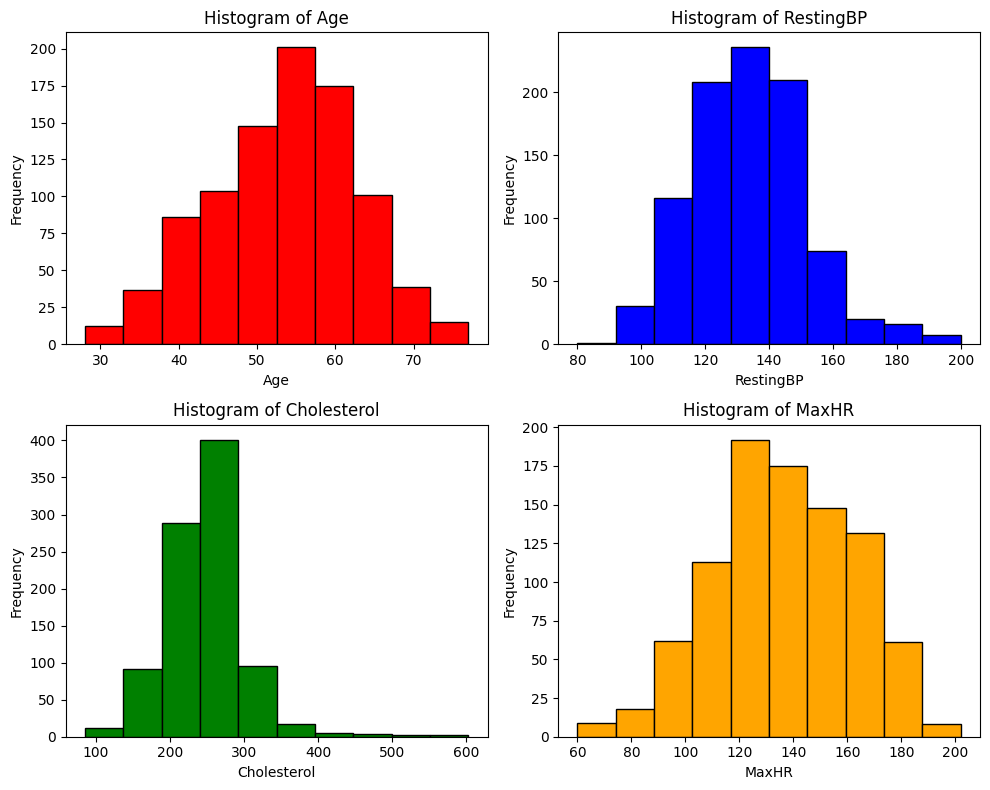

In [8]:
# Question 6 (Visualizing the Data Using Histogram)

def Heart_hist(df, column, color, pos):
    plt.subplot(2, 2, pos)
    plt.hist(df[column], bins=10, color=color, edgecolor="black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.figure(figsize=(10,8))

Heart_hist(df, "Age", "red", 1)
Heart_hist(df, "RestingBP", "blue", 2)
Heart_hist(df, "Cholesterol", "green", 3)
Heart_hist(df, "MaxHR", "orange", 4)

plt.tight_layout()
plt.show()

In [9]:
#Question 7 ( Identifying and printing numerical columns and categorical columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Columns:", numerical_columns)
print("\n\nCategorical Columns:", categorical_columns)


Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [10]:
# Question 8 ( Encoding categorical columns using one-hot encoding)
df_encoded = pd.get_dummies(df, columns=categorical_columns)

print("\nFirst 5 Rows of Encoded DataFrame:")
print(df_encoded.head())


First 5 Rows of Encoded DataFrame:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_No

In [11]:
# Question 9 (Final shape and column names after cleaning and encoding)

print("\nFinal Shape of df_encoded:", df_encoded.shape)

print("\nColumns in df_encoded:")

print(df_encoded.columns.tolist())


Final Shape of df_encoded: (918, 21)

Columns in df_encoded:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


**Question 10 Visualization** 

# Summary

## What invalid values were found and how were they fixed?

- The dataset contained:
  - `172` rows where **Cholesterol = 0**
  - `1` row where **RestingBP = 0**
- These values were considered invalid because cholesterol and resting blood pressure cannot be zero in a real patient.
- The invalid values were replaced with the mean of the non-zero values using:
  - `chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()`
  - `bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()`
  - `df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)`
  - `df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)`

## Why is it important to handle invalid values?

- Invalid values can produce inaccurate statistical results.
- They may reduce the performance of machine learning models.
- Replacing invalid values improves the quality, consistency, and reliability of the dataset.

## What is the purpose of One-Hot Encoding?

- One-Hot Encoding converts categorical columns into numerical (binary) columns.
- It creates a separate column for each category, such as `Sex_M`, `Sex_F`, `ChestPainType_ATA`, etc.
- This enables machine learning algorithms to process categorical data effectively.
- It was performed using:
  - `df_encoded = pd.get_dummies(df, columns=categorical_columns)`

## Other observations from the cleaning process

- No missing (null) values were found in the dataset.
- No duplicate rows were found.
- The dataset was successfully cleaned and prepared for further analysis.
- Histograms were plotted to visualize the distribution of numerical features.
- After One-Hot Encoding, the encoded dataframe contained more columns because each categorical value was converted into a separate binary feature.